## Using LSTM with Feature Engineering to Train Multiple Stock
### Sector/Subsector: Utilities > Ticker: WEC, LNT, AWK

<p> Date: 2026-11-15 &emsp;&emsp;&emsp; 
<br><br> 

**Source Data**: [New York Stock Exchange](https://www.kaggle.com/datasets/dgawlik/nyse?select=securities.csv)

**Content:** <br>
- [Background](#background)

- [Experiemnt 🧪⚗️ ](#experiment)
    
    - [Feature engineering](#2-feature-engineering): volume change, 7-day return, streak up, streak down, range ratio 

    - [Modeling](#modeling)

    - [Robustness Performance Analysis](#robustness-performance-analysis)

    - [Prediction](#Prediction)

- [Reference]() 

## Background

### 1. Stock Analysis using Recurrent Neural Networks (RNNs): LSTM = Long Short-Term Memory`;

1. Recurrent Neural Networks (RNNs) – especially LSTM/GRU
    - `LSTM = Long Short-Term Memory`; GRU = Gated Recurrent Units  
    - The classic approach: use a sequence of past price (and optionally volume/indicators) to forecast next price or return. e.g., using TensorFlow / Keras you can build a straightforward LSTM model. 
    - Example: Using x_train of shape (time_steps, features) and LSTM layers, return_sequences, etc. 
    - Also GRU variants (Gated Recurrent Units) appear in literature. 

### 2. Feature Engineering

Adding open, high, low, and volume can help, but whether it improves your model depends on multiple factors:

1. Why adding them could help
    - Open, high, low: Provide intra-day movement information. LSTM can potentially capture patterns like volatility, gaps, etc.
    - Volume: Often correlates with price momentum and can indicate strong buying/selling pressure. LSTM could learn relationships between volume spikes and price changes.

2. Why it might not help
    - **Redundancy**: Closing price is already a summary of the day. High and low may not add much signal if your prediction horizon is daily and the LSTM captures trends from closing prices.
    - **Noise**: Extra features introduce more parameters for the model to learn. If the stock’s movement is mostly trend-based and predictable from the close price alone, extra features could just add noise.
    - **Data scarcity**: For short time series (like <2000 days), adding more features increases risk of overfitting.

**Rule of thumb**: Adding more features can help but is not guaranteed. It’s better to test feature sets and validate than assume more features always improve LSTM performance.


### 2.1 Table 

| Feature Nam         | Description / How to Compute                                            | Notes / Why Useful                        |
| ------------------- | ----------------------------------------------------------------------- | ----------------------------------------- |
| Close               | Closing price of the day                                                | Baseline target for prediction            |
| Open                | Opening price                                                           | Optional: can capture gap moves           |
| High                | Daily high                                                              | Helps measure intra-day extremes          |
| Low                 | Daily low                                                               | Combined with High, gives volatility info |
| Volume              | Trading volume                                                          | Indicates buying/selling pressure         |
| **Volume_Change**       | `(Volume_t - Volume_{t-1}) / Volume_{t-1}`                              | Detects unusual volume spikes             |
| Return_1d           | `(Close_t - Close_{t-1}) / Close_{t-1}`                                 | Daily return / momentum                   |
| **Return_7d**           | `(Close_t - Close_{t-7}) / Close_{t-7}`                                 | Short-term momentum                       |
| **Streak_Up**           | Count of consecutive days `Close_t > Close_{t-1}`                       | Captures buying pressure                  |
| **Streak_Down**         | Count of consecutive days `Close_t < Close_{t-1}`                       | Captures selling pressure                 |
| ATR_7               | Average True Range over 7 days: mean of `(High - Low)` or `(max - min)` | Measures short-term volatility            |
| MA_5                | 5-day moving average of close                                           | Trend indicator                           |
| MA_10               | 10-day moving average of close                                          | Trend indicator                           |
| MA_ratio            | `MA_5 / MA_10`                                                          | Crossovers may indicate momentum shifts   |
| Price_Volume_Signal | `Return_1d * Volume_Change`                                             | Combined price + volume momentum signal   |
| True Range(TR)      | `max(High - Low, abs(High - PrevClose), abs(Low - PrevClose))           | Captures true daily volatility including overnight gaps |
|**Range Ratio**      | `(High - Low) / Close`                                                  |Simpler, normalized volatility measure — used in quantitative screening and neural network inputs.| 



## Experiment


In [1]:
# ##### ===== System Setup ==== ##### uncomment the code below for a more automatic folder and log function 
import time 
start_time = time.time()

# %load_ext dotenv
# %dotenv
# # utility
# import os, sys
# print(os.getenv('SRC_DIR'))
# sys.path.append(os.getenv('SRC_DIR'))

# # set up logger
# from utils.logger import get_logger
# from datetime import datetime
# _logs = get_logger(__name__)
# _logs.info(f"Hello World! Today is {datetime.now().strftime('%A, %B %d, %Y')}")

# sys.path.append(os.getenv('SRC_DIR'))

In [2]:
##### >>> 1: Testing with APPL(Apple)  

### >> 1.1 Load Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler


2025-11-16 02:20:57.922848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-16 02:20:57.941382: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-16 02:20:57.947023: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-16 02:20:57.958723: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-16 02:20:58.922575: W tensorflow/compiler/tf2

In [3]:
##### >>> 2.1 Extract sector and subsectors

### >>  map price data to the GICs sectors
df_security = pd.read_csv("../data/raw/securities.csv")
# creates a dictionary that maps ticker to its GICS sector
df_security_sub = df_security.copy()
df_security_sub = df_security_sub[df_security_sub['GICS Sector']=='Utilities']
# df_security_sub = df_security_sub[df_security_sub['GICS Sub Industry']=='Semiconductor Equipment']
Tick = ['AWK','LNT','WEC']

In [4]:
### >> 2.2 Load the price data: AWK, LNT, WEC
FILE_PATH = "../data/raw"
RAW_FILE = os.path.join(FILE_PATH, "prices-split-adjusted.csv")

df = pd.read_csv(RAW_FILE, parse_dates=["date"])
df = df.groupby('symbol').filter(lambda x: len(x) > 1500)  # only select more data with more than 1500 records 
# check for NaN or Null 
print(df.isnull().sum())
print(f"Any NA: {df.isna().any().any()}")  # False
print(f"Ticker: {Tick}")

# set data as index
df = df[df["symbol"].isin(Tick)]
df = df[["date","symbol","open", "high", "low", "close", "volume"]].set_index("date")
print(f"start date: {df.index[0].strftime('%Y-%m-%d')}; end date: {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of record: {len(df)}")


date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64
Any NA: False
Ticker: ['AWK', 'LNT', 'WEC']
start date: 2010-01-04; end date: 2016-12-30
Number of record: 5286


In [5]:
df

,symbol,open,high,low,close,volume
date,,,,,,
2010-01-04,AWK,22.410000,22.860001,22.410000,22.650000,2176100.0
2010-01-04,LNT,15.245000,15.350001,15.120000,15.175000,1332800.0
2010-01-04,WEC,25.024999,25.075001,24.764999,24.865000,1541800.0
2010-01-05,AWK,22.670000,22.910000,22.590000,22.879999,1843600.0
2010-01-05,LNT,15.185000,15.555001,15.155000,15.530000,3684600.0
...,...,...,...,...,...,...
2016-12-29,LNT,37.660000,38.240002,37.549999,38.189999,627300.0
2016-12-29,WEC,58.189999,58.900002,57.959999,58.849998,1250500.0
2016-12-30,AWK,72.660004,72.889999,72.029999,72.360001,775400.0


In [6]:
# ============================================================
# >> 1.3 Feature Engineering
# ============================================================

### >> Help Function: Feature engineering
def add_stock_features(df):
    """
    Add engineered features to a stock price DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        Stock data with columns: ['open','high','low','close','volume'] and date as index.
    
    Returns
    -------
    pd.DataFrame
        Original DataFrame with new features:
        - vol_change: % change in volume
        - return_7d: 7-day return %
        - streak_up: consecutive up days
        - streak_down: consecutive down days
        - range_ratio: normalized daily volatility
    """
    df = df.copy()
    
    # 1. Volume change (%)
    if 'volume' in df.columns:
        df['vol_change'] = df['volume'].pct_change()
    else:
        df['vol_change'] = np.nan

    # 2. 7-day return (%)
    df['return_7d'] = df['close'].pct_change(periods=7)

    # 3. Streak up (consecutive up days)
    streak_up = []
    count = 0
    for i in range(len(df)):
        if i == 0:
            count = 0
        elif df['close'].iloc[i] > df['close'].iloc[i - 1]:
            count += 1
        else:
            count = 0
        streak_up.append(count)
    df['streak_up'] = streak_up

    # 4. Streak down (consecutive down days)
    streak_down = []
    count = 0
    for i in range(len(df)):
        if i == 0:
            count = 0
        elif df['close'].iloc[i] < df['close'].iloc[i - 1]:
            count += 1
        else:
            count = 0
        streak_down.append(count)
    df['streak_down'] = streak_down

    # 5. Range ratio (normalized daily volatility)
    if {'high', 'low'}.issubset(df.columns):
        df['range_ratio'] = (df['high'] - df['low']) / df['close']
    else:
        df['range_ratio'] = np.nan

    # Drop initial NaN from pct_change calculations
    df = df.dropna()

    return df


In [7]:
# Apply feature engineering per stock
df = df.sort_values(['symbol','date'])

df_fe = (
    df.groupby('symbol',group_keys=False)
      .apply(lambda x: add_stock_features(x))
)

/tmp/ipykernel_759555/3885366917.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('symbol',group_keys=False)


In [8]:
df_fe

,symbol,open,high,low,close,volume,vol_change,return_7d,streak_up,streak_down,range_ratio
date,,,,,,,,,,,
2010-01-13,AWK,23.080000,23.320000,23.000000,23.219999,703600.0,-0.370380,0.025166,1,0,0.013781
2010-01-14,AWK,23.120001,23.150000,22.879999,22.980000,1173700.0,0.668135,0.004371,0,1,0.011749
2010-01-15,AWK,23.059999,23.059999,22.430000,22.600000,996700.0,-0.150805,-0.017391,0,2,0.027876
2010-01-19,AWK,22.690001,22.809999,22.500000,22.500000,779500.0,-0.217919,-0.023861,0,3,0.013778
2010-01-20,AWK,22.590000,22.600000,22.209999,22.450001,1438800.0,0.845799,-0.023913,0,4,0.017372
...,...,...,...,...,...,...,...,...,...,...,...
2016-12-23,WEC,58.820000,58.930000,58.529999,58.730000,622300.0,-0.426504,0.031980,7,0,0.006811
2016-12-27,WEC,58.720001,58.770000,58.130001,58.570000,730500.0,0.173871,0.025026,0,1,0.010927
2016-12-28,WEC,58.560001,58.720001,57.880001,57.900002,904300.0,0.237919,-0.001896,0,2,0.014508


## Modeling

**Key Concept**

1. **`create_dataset`**:

    - series[i:i+look_back]: takes a window of look_back consecutive days as input.  

    - series[i+look_back]: the next day after the window is the target.  

    | Input window (`X`) | Target (`y`) |
    | ------------------ | ------------ |
    | day 0–19           | day 20       |
    | day 1–20           | day 21       |
    | day 2–21           | day 22       |
    | …                  | …            |

    For a series of length 100, the number of (X, y) pairs is: 

    <p style="text-align:left;"><em>&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;100 - 20 = 80</em></p>

    So you end up with 80 rows of training data

2. `model.fit()`: set shuffle = False as this is time series 

3. 

```text
            ┌─────────────────────────────────────────┐
            │               Input Layer               │
            │         (20 timesteps × 6 features)     │
            └────────────────────┬────────────────────┘
                                 │
                                 ▼
            ┌─────────────────────────────────────────┐
            │                LSTM Layer               │
            │              50 hidden units            │
            │      Learns temporal dependencies       │
            │                                         │
            │           Total params: 126,755         │
            │           Trainable params: 42,251      │
            │           Non-trainable params: 0       │
            │           Optimizer params: 84,504      │
            └─────────────────────┬───────────────────┘
                                  │
                                  ▼
            ┌─────────────────────────────────────────┐
            │               Dense Output              │
            │                 (1 neuron)              │
            │           Predicts next-day price       │
            └─────────────────────────────────────────┘

```

In [9]:
## >> check the index for close
target_col = df_fe.columns.get_loc('close')
print(f"Target: close; Column index = {target_col}")

Target: close; Column index = 4


In [10]:
##### >>> 2. LSTM Model Construction 

# Scale data
# scaler = MinMaxScaler()
features = df_fe.select_dtypes(include=[np.number]).columns.tolist()
# scaled = scaler.fit_transform(df_fe[features])

# define a helper fucntion to create a training data as input sequence (the sliding window and look_back = 20)
# with a multiple input columns, each y should usually predict one target (e.g., next-day close), not the full feature vector -> add # target_col
def create_dataset(series, look_back, target_col=4):   # target close price
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i+look_back, :]) # all features for look_back days
        y.append(series[i+look_back, target_col])
    return np.array(X), np.array(y)

## ============================ ##
##    Input Prepare Function    ##
## ============================ ##

def prepare_input(df_fe, features, target_feature='close', look_back=20):
    X_list, y_list = [], []
    scalers = {}  # dictionary to store scaler per stock

    for symbol in df_fe['symbol'].unique():
        df_s = df_fe[df_fe['symbol'] == symbol]
        scaler_s = MinMaxScaler()
        scaled_s = scaler_s.fit_transform(df_s[features])
        
        # save scaler for this stock
        scalers[symbol] = scaler_s

        target_col = features.index(target_feature)
        X_s, y_s = create_dataset(scaled_s, look_back, target_col)
        
        X_list.append(X_s)
        y_list.append(y_s)

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    
    return X, y, scalers  # return dictionary of scalers


## ===================================== ##
##    train / validation / test split    ##
## ===================================== ##
# create train, test data for both x and y

def train_val_test_split(X, y, val_ratio=0.2, test_ratio=0.2):
    n_total = len(X)
    n_test = int(n_total * test_ratio)
    n_val = int((n_total - n_test) * val_ratio)
    
    X_train = X[:-(n_val + n_test)]
    y_train = y[:-(n_val + n_test)]
    
    X_val = X[-(n_val + n_test):-n_test]
    y_val = y[-(n_val + n_test):-n_test]
    
    X_test = X[-n_test:]
    y_test = y[-n_test:]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

#### **LSTM expects input in 3D shape**

| Dimension| Symbol             | Example value | Meaning                                                           |
| ---------| ------------------ | ------------- | ----------------------------------------------------------------- |
| 1        | `X_train.shape[0]` | e.g. 3000     | Number of sequences (samples) you created from your data          |
| 2        | `X_train.shape[1]` | e.g. 60       | Number of **time steps** in each sequence (the “lookback window”) |
| 3        | `X_train.shape[2]` | e.g. 1        | Number of **features per time step** (columns in your input)      |


Another way to think about is:
1. Time step ([1]): How many past days the model looks back? 
2. Feature per time step ([2]):	How many variables per day? only close or open, close,? 


#### Different Metrics Guide

| Metric                                    | Penalizes Large Errors? |  Scale-Dependent? |          Robust to Outliers?          | Gradient Behavior                                                                              | Common Use / Strength                                                           | Drawbacks                                                   | Best For                                                                   |
| :---------------------------------------- | :---------------------: | :---------------: | :-----------------------------------: | :--------------------------------------------------------------------------------------------- | :------------------------------------------------------------------------------ | :---------------------------------------------------------- | :------------------------------------------------------------------------- |
| **MSE** (Mean Squared Error)              |        ✅ Strongly       |       ✅ Yes       |                  ❌ No                 | ✅ Smooth, differentiable everywhere; larger gradients for bigger errors → good for neural nets | Emphasizes large mistakes; useful in training models (esp. NN/gradient descent) | Harder to interpret (units²); overly influenced by outliers | Optimizing NN models or when you want to heavily penalize large deviations |
| **RMSE** (Root Mean Squared Error)        |       ✅ Moderately      |       ✅ Yes       |                  ❌ No                 | ✅ Smooth (same as MSE, just transformed)                                                       | Same benefits as MSE but interpretable (same units as target)                   | Still sensitive to large errors                             | Reporting model accuracy in stock price units                              |
| **MAE** (Mean Absolute Error)             |         ❌ Linear        |       ✅ Yes       |                 ✅ Yes                 | ⚠️ Constant gradient almost everywhere, not smooth at zero → slower NN convergence             | Stable metric; simple to explain (“avg error = $X”)                             | Slower training in NN; doesn’t highlight big mistakes       | Evaluating performance robustly or for non-NN models                       |
| **MAPE** (Mean Absolute Percentage Error) |         ❌ Linear        | ❌ No (unitless %) | ❌ No (unstable for small true values) | ⚠️ Non-smooth due to division by target                                                        | Easy to interpret as percentage error; good for cross-stock comparison          | Undefined/unstable if price ≈ 0; biased toward low values   | Comparing models across stocks with different price ranges                 |



In [11]:
# Prepare sequences and confirm target column index
X, y, scaler = prepare_input(df_fe, features, target_feature='close', look_back=20)
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)
print("Shapes:", X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

target_col = df_fe.columns.get_loc('close')
print(f"Target: close; Column index = {target_col}")

Shapes: (3332, 20, 10) (3332,) (832, 20, 10) (832,) (1041, 20, 10) (1041,)
Target: close; Column index = 4


In [12]:
## LSTM model ver2

def create_lstm_model_v2(input_shape):
    model = Sequential([
        tf.keras.Input(shape=input_shape),
        LSTM(64, activation='tanh', return_sequences=True),  # 50 memory unit, common values are :32, 50. 64
        LSTM(50, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [13]:
##### >>> 3.2 Train LSTM : with better model 
from tqdm import tqdm

metrics=[]
histories=[]
predictions=[]
seeds=[111,222,333]

look_back = 20

for symbol in tqdm(df_fe['symbol'].unique()):
    # only select one symobl 
    df_s = df_fe[df_fe['symbol'] == symbol].copy() 

    scaler = MinMaxScaler()
    scaled_s = scaler.fit_transform(df_s[features])
    
    # scaled_s = scaler.fit_transform(df_fe[features])

    X_s, y_s = create_dataset(scaled_s, look_back, target_col)
    X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X_s, y_s)

    for i in tqdm(range(3),leave=False): 
        random.seed(seeds[i])
        np.random.seed(seeds[i])
        tf.random.set_seed(seeds[i])
        ## >> Train
        n_steps = X_train.shape[1]; 
        n_features = scaler.n_features_in_
        # n_features = X_train.shape[2]
        model_lstm = create_lstm_model_v2((n_steps,n_features))
        
        history = model_lstm.fit(X_train, y_train, validation_data=(X_val, y_val), 
                                shuffle=False, epochs=20, batch_size=16, verbose=0) # time series, need to set shuffer = False
        
        histories.append({
            "symbol": symbol,
            "Run": i+1,
            "Seed": seeds[i],
            "history": history.history})

        ## >> Predict
        y_pred = model_lstm.predict(X_test)
        # Prepare y_pred for inverse transform
        y_pred_pad = np.zeros((len(y_pred), n_features))
        y_pred_pad[:, target_col] = y_pred.flatten()   # put predicted close into the first column
        y_pred_inv = scaler.inverse_transform(y_pred_pad)[:, target_col]  # take only the close column

        # Same for y_test
        y_test_pad = np.zeros((len(y_test), n_features))
        y_test_pad[:, target_col] = y_test.flatten()
        y_test_inv = scaler.inverse_transform(y_test_pad)[:, target_col]

        residuals = y_test_inv - y_pred_inv
        
        ## >> Save individual run results
        predictions.append({
            "symbol" : symbol,
            "Run": i+1,
            "Seed": seeds[i],
            "y_test": y_test_inv.copy(),
            "y_pred": y_pred_inv.copy()
        })

        # Metrics
        mse = mean_squared_error(y_test_inv, y_pred_inv)
        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs(residuals / y_test_inv)) * 100
        # Compute directional accuracy
        # np.diff calculates day-to-day changes
        # np.sign gets the direction (+1 up, -1 down)
        direction_match = np.sign(np.diff(y_pred_inv, axis=0)) == np.sign(np.diff(y_test_inv, axis=0))
        direction_accuracy = np.mean(direction_match) * 100  # convert to percentage

        # --- Save results for comparison ---
        metrics.append({
            "Ticker": symbol,
            "Run": i+1,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "DirAcc (%)": direction_accuracy
         })
model_lstm.summary()

results_metrics_df = pd.DataFrame(metrics)

print(results_metrics_df.to_string(index=False, float_format="%.4f"))

  0%|          | 0/3 [00:00<?, ?it/s]

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


 33%|███▎      | 1/3 [00:45<01:30, 45.19s/it]

...

 Total params: 126,755 (495.14 KB)

 Trainable params: 42,251 (165.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 84,504 (330.10 KB)

Ticker  Run                MSE         RMSE         MAE    MAPE  DirAcc (%)
   AWK    1 3870153405325.6865 1967270.5471 617015.1072 37.2336     41.6185
   AWK    2 3911686738808.9062 1977798.4576 625638.7405 38.5574     42.4855
   AWK    3 3926702625402.7104 1981590.9329 629552.2198 38.1451     41.0405
   LNT    1 8378301019864.0723 2894529.4989 787639.5030 45.6422     47.1098
   LNT    2 8430703829349.3398 2903567.4315 805886.7969 46.4694     47.3988
   LNT    3 8214205825413.8242 2866043.5840 719421.9211 39.4105     47.1098
   WEC    1  662336806023.1191  813840.7744 674281.5787 43.2828     40.1734
   WEC    2  626103761774.0386  791267.1873 649633.1609 41.4378     40.1734
   WEC    3  721910790125.9999  849653.3353 710213.3088 45.6220     40.7514


In [14]:
stop_time1 = time.time()  # record end
print(f"Training time1: {stop_time1 - start_time:.4f} seconds")  # calcultion

Training time1: 141.5467 seconds


In [ ]:
### 3.2 training plot

## ================================= ## 
##  function to plot trainig history ##
## ================================= ## 
def plot_training_history(symbol, histories, outdir="."):

    plt.figure(figsize=(10, 6))

    # Filter histories for this symbol
    hlist = [h for h in histories if h["symbol"] == symbol]

    for h in hlist:
        run = h["Run"]
        hist = h["history"]

        plt.plot(hist["loss"], label=f'Run {run} Train Loss')
        plt.plot(hist["val_loss"], '--', label=f'Run {run} Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(f'{symbol}: LSTM Training and Validation Loss Across 3 Runs')
    plt.legend()
    plt.grid(True)

    plt.savefig(f"{outdir}/{symbol}_training_loss.png", dpi=300, bbox_inches='tight')
    plt.show()



In [22]:
Tick

['AWK', 'LNT', 'WEC']

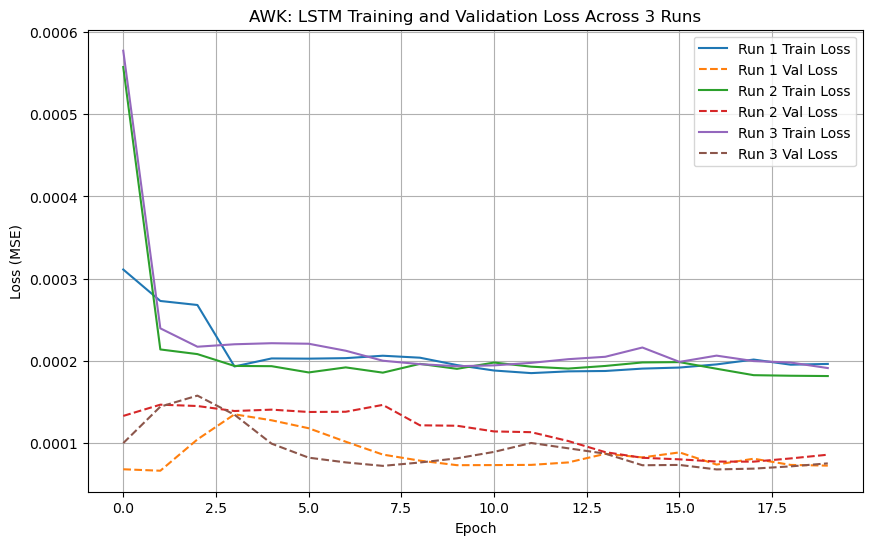

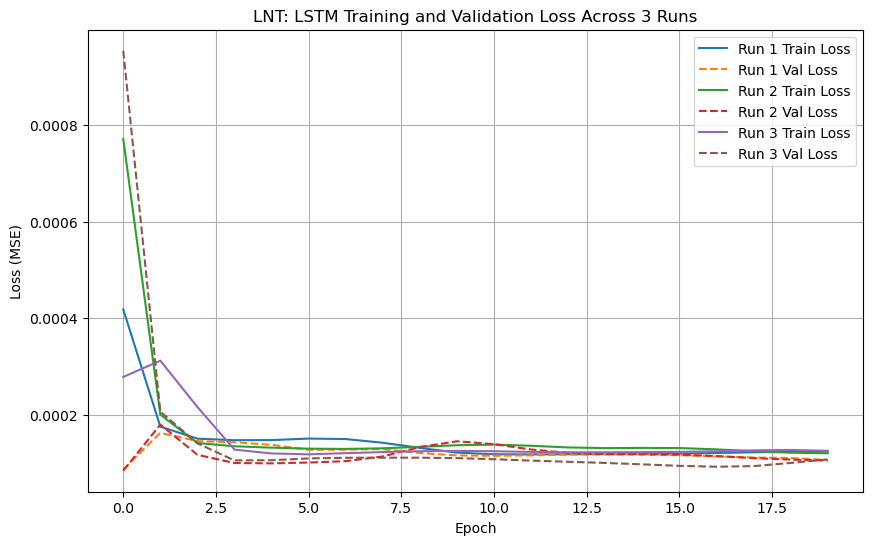

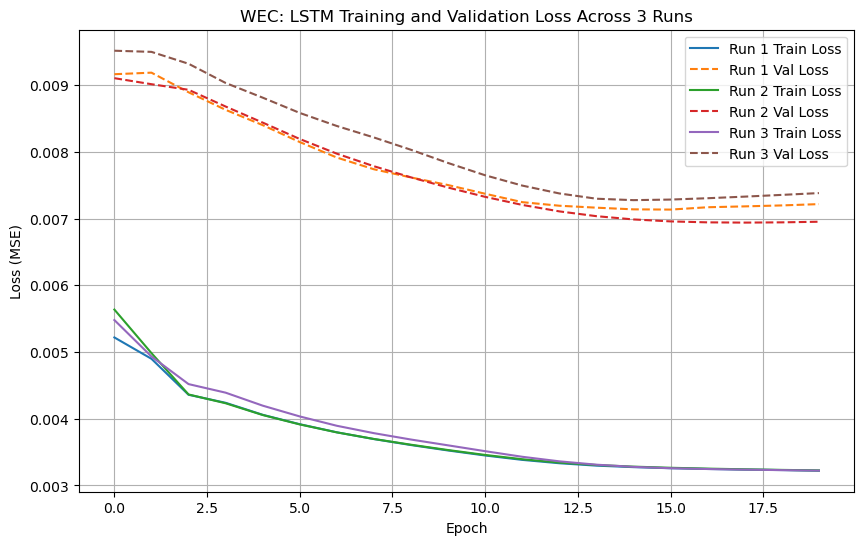

In [23]:
for i in Tick: 
    plot_training_history(symbol=i, histories=histories)


## Robustness Performance Analysis

In [19]:
## 4.1 Residual plot

## ============================ ## 
##  function for resisdual plot ##
## ============================ ## 

def plot_residuals_for_ticker(predictions, ticker):
    """
    Plot residual-over-time and histogram for all seeds of a given ticker.
    predictions: list of dicts
    ticker: string such as 'MSFT' or 'INTC'
    """
    
    # Filter predictions for that ticker
    preds = [p for p in predictions if p["symbol"] == ticker]
    
    if len(preds) == 0:
        print(f"No predictions found for ticker: {ticker}")
        return
    
    for pred in preds:
        residuals = pred["y_test"] - pred["y_pred"]
        seed = pred.get("Seed", "N/A")

        # Residual over time
        plt.figure(figsize=(10,4))
        plt.plot(residuals)
        plt.title(f"{ticker}: Residuals Over Time - Seed {seed}")
        plt.xlabel("Time Index")
        plt.ylabel("Residual")
        plt.grid(True, alpha=0.3)
        plt.show()

        # Residual histogram
        plt.figure(figsize=(6,4))
        plt.hist(residuals, bins=50, alpha=0.7)
        plt.title(f"{ticker}: Residual Distribution - Seed {seed}")
        plt.xlabel("Residual")
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()


Tick

['AWK', 'LNT', 'WEC']

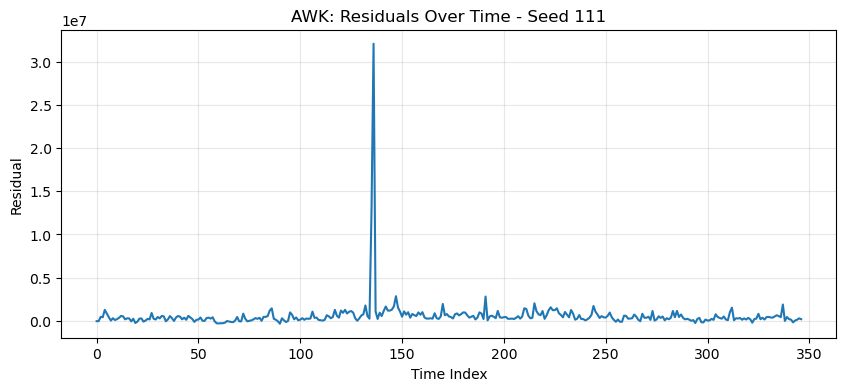

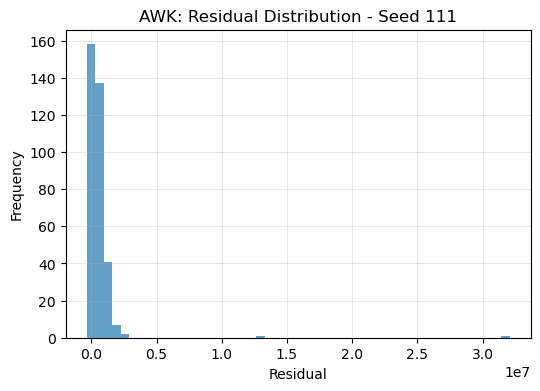

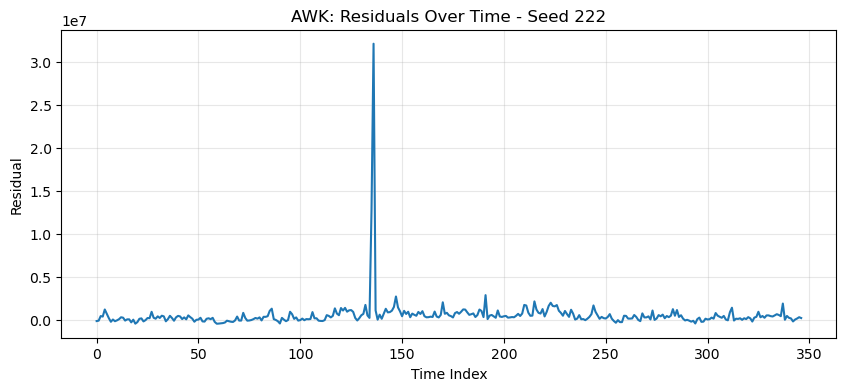

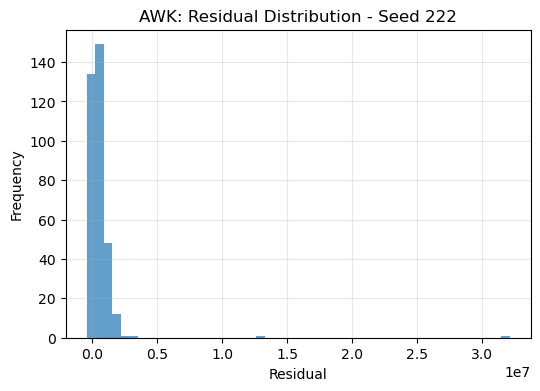

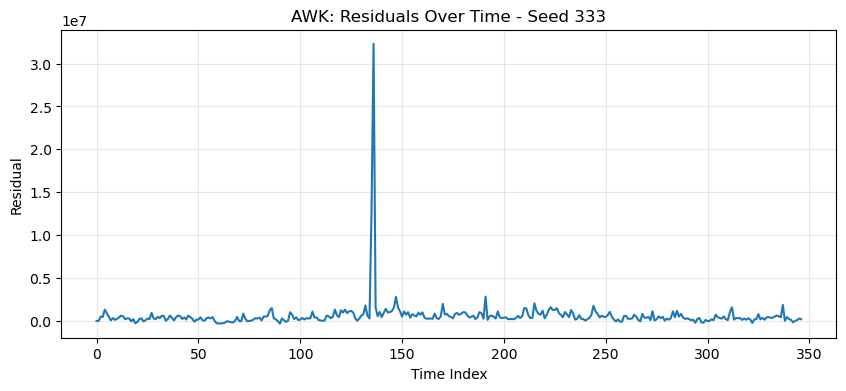

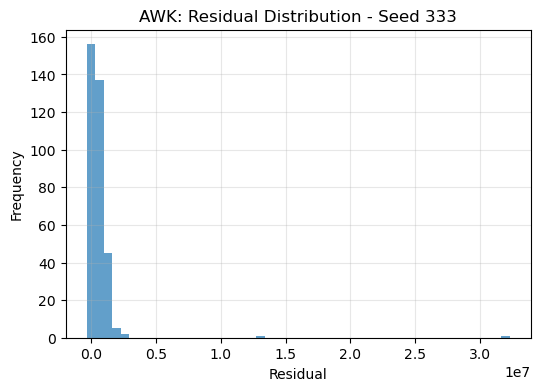

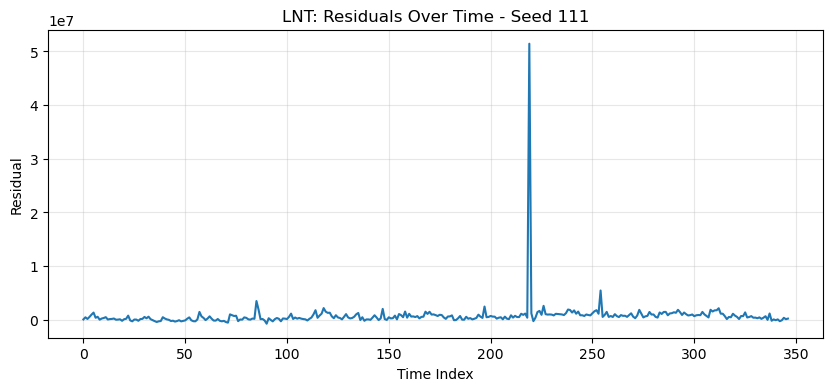

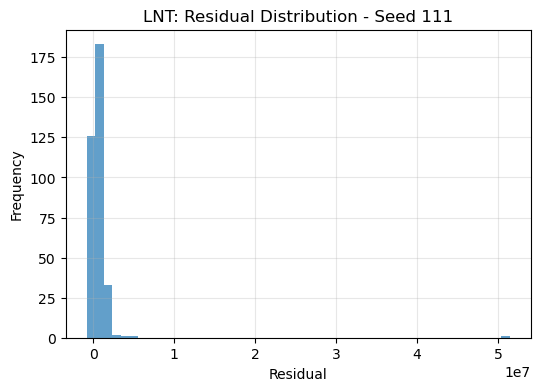

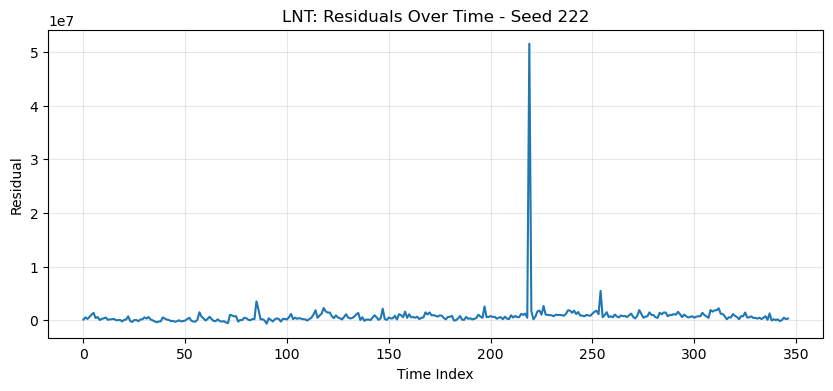

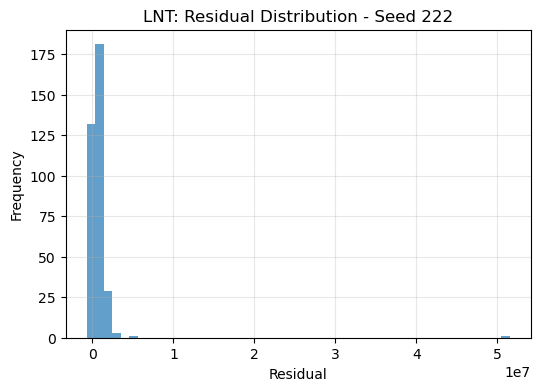

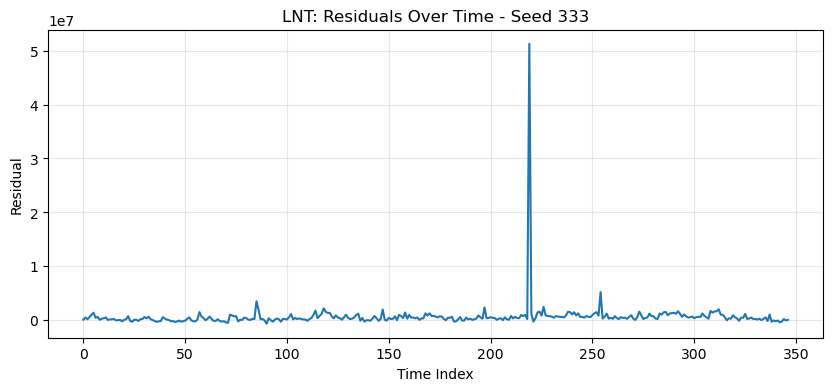

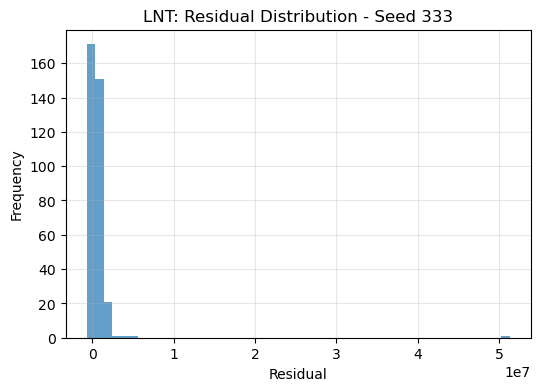

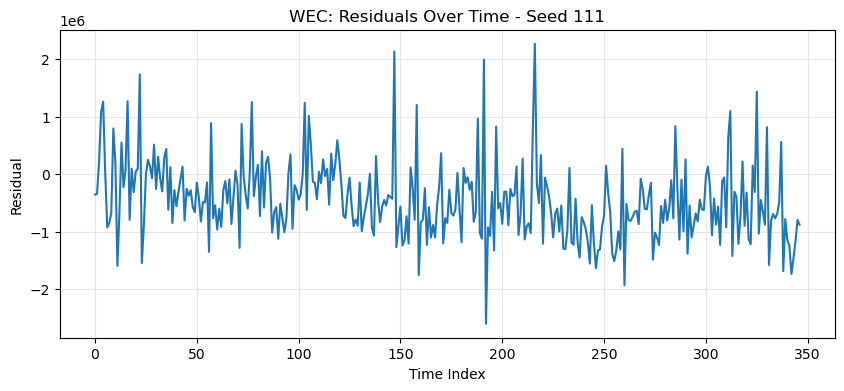

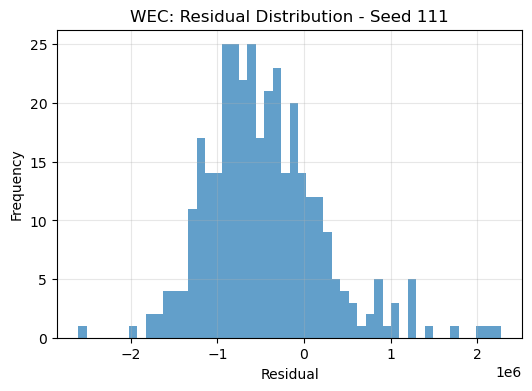

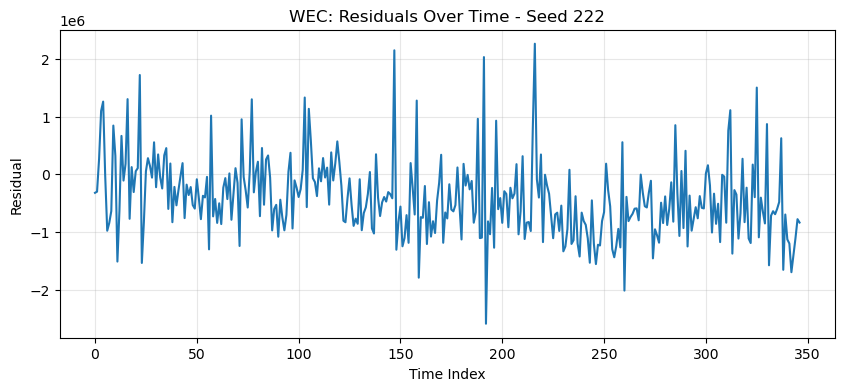

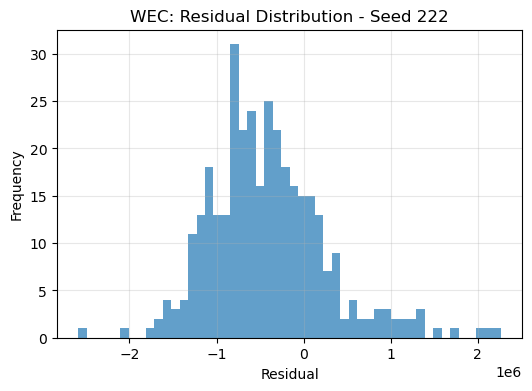

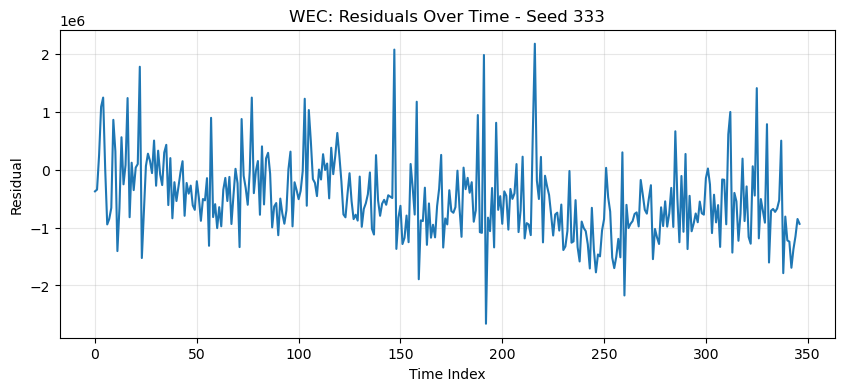

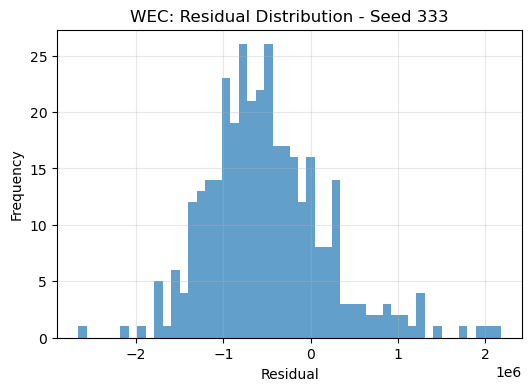

In [20]:
for t in Tick:
    plot_residuals_for_ticker(predictions, t)

In [21]:
end_time = time.time()  # record end
print(f"Total runtime: {end_time - start_time:.4f} seconds")  # calcultion

Total runtime: 145.2432 seconds
